# RFM - Customer Segmentation using Pandas

**Assignment Tasks:**
1. Define the recency, frequency, and monetary model in the context of customer segmentation process.
2. Use the attached dataset to calculate the recency, frequency, and monetary values for each customer.
3. Search for the scientific way to arrange the customer list using the RFM model.
4. Search for the most usable charts that can visualize the results of the RFM model.

**Dataset:** Sample - Superstore 2019 (cleaned parquet version)

## 1. Definition of the RFM Model in Customer Segmentation

The **RFM model** is a proven, data-driven customer segmentation technique widely used in marketing analytics and CRM. It evaluates customers based on three key behavioral dimensions derived from transactional data:

### Recency (R)
- **Definition:** How recently a customer made a purchase.
- **Calculation:** Number of days between the customer's most recent purchase date and a reference date (usually the last date in the dataset or "today").
- **Interpretation:** Customers with **lower Recency** (recent purchases) are more likely to respond to promotions and remain engaged. High Recency indicates potential churn risk.

### Frequency (F)
- **Definition:** How often a customer makes purchases within a given time period.
- **Calculation:** Count of distinct orders (or transactions) placed by the customer.
- **Interpretation:** Higher Frequency indicates loyal or habitual buyers who are more valuable and easier to retain.

### Monetary (M)
- **Definition:** How much money a customer has spent in total (or average spend per order).
- **Calculation:** Sum of sales (or profit) across all of the customer's transactions.
- **Interpretation:** Higher Monetary value identifies high-value customers who contribute the most revenue.

### Why RFM for Customer Segmentation?
- It is **simple**, **interpretable**, and requires only transactional data (no demographics needed).
- It follows the marketing principle that **past behavior is the best predictor of future behavior**.
- Customers are scored (usually 1–5) on each dimension and combined into RFM segments.
- Enables targeted marketing: re-engage dormant customers, reward loyal high-spenders, upsell mid-tier customers, etc.

**Classic reference:** The RFM concept originated in direct mail marketing and was formalized in database marketing literature (e.g., Hughes, 1994; later popularized in retail analytics).

## 2. Calculate Recency, Frequency, and Monetary Values for Each Customer

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
from datetime import datetime

df = pd.read_parquet("Sample - Superstore 2019_clean.parquet", engine='pyarrow')
df.shape

(9993, 20)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [17]:
df_clean = df.copy()
df_clean.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9993 non-null   str           
 1   Order Date      9993 non-null   datetime64[us]
 2   Ship Date       9993 non-null   datetime64[us]
 3   Ship Mode       9993 non-null   category      
 4   Customer ID     9993 non-null   str           
 5   Customer Name   9993 non-null   str           
 6   Segment         9993 non-null   category      
 7   Country/Region  9993 non-null   category      
 8   City            9993 non-null   str           
 9   State           9993 non-null   category      
 10  Postal Code     9993 non-null   str           
 11  Region          9993 non-null   category      
 12  Product ID      9993 non-null   str           
 13  Category        9993 non-null   category      
 14  Sub-Category    9993 non-null   category      
 15  Product Name   

In [18]:
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
print('Reference date used for Recency:', reference_date.date())

rfm = df.groupby('Customer ID').agg(
    Customer_Name = ('Customer Name', 'first'),
    Segment       = ('Segment', 'first'),
    Recency       = ('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency     = ('Order ID', 'nunique'),         
    Monetary      = ('Sales', 'sum')                  
).reset_index()
print('RFM table shape:', rfm.shape)
rfm.head(10)


Reference date used for Recency: 2019-12-31
RFM table shape: (793, 6)


,Customer ID,Customer_Name,Segment,Recency,Frequency,Monetary
0,Aa-10315,Alex Avila,Consumer,185,5,5563.560
1,Aa-10375,Allen Armold,Consumer,20,9,1056.390
2,Aa-10480,Andrew Allen,Consumer,260,4,1790.512
3,Aa-10645,Anna Andreadi,Consumer,56,6,5086.935
4,Ab-10015,Aaron Bergman,Consumer,416,3,886.156
5,Ab-10060,Adam Bellavance,Home Office,55,8,7755.620
6,Ab-10105,Adrian Barton,Consumer,42,10,14473.571
7,Ab-10150,Aimee Bixby,Consumer,42,5,966.710
8,Ab-10165,Alan Barnes,Consumer,26,8,1113.838
9,Ab-10255,Alejandro Ballentine,Home Office,167,9,914.532


## 3. Scientific Way to Arrange / Rank Customers using the RFM Model


In [19]:
# ---------------------------------------------------------------
# Quintile Scoring (Scientific RFM Ranking)
# ---------------------------------------------------------------

# Recency: lower days = better → we reverse the labels
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency & Monetary: higher = better
# Note: Frequency has ties; qcut may fail on perfect ties → use rank method if needed
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM Score (string and numeric)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm.head(10)

,Customer ID,Customer_Name,Segment,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,Aa-10315,Alex Avila,Consumer,185,5,5563.560,2,2,5,225,9
1,Aa-10375,Allen Armold,Consumer,20,9,1056.390,5,5,2,552,12
2,Aa-10480,Andrew Allen,Consumer,260,4,1790.512,1,1,3,113,5
3,Aa-10645,Anna Andreadi,Consumer,56,6,5086.935,3,3,5,335,11
4,Ab-10015,Aaron Bergman,Consumer,416,3,886.156,1,1,1,111,3
5,Ab-10060,Adam Bellavance,Home Office,55,8,7755.620,3,4,5,345,12
6,Ab-10105,Adrian Barton,Consumer,42,10,14473.571,4,5,5,455,14
7,Ab-10150,Aimee Bixby,Consumer,42,5,966.710,4,2,2,422,8
8,Ab-10165,Alan Barnes,Consumer,26,8,1113.838,5,4,2,542,11
9,Ab-10255,Alejandro Ballentine,Home Office,167,9,914.532,2,5,1,251,8


In [27]:
# Define meaningful customer segments based on RFM scores
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    total = row['RFM_Total']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Promising / New Customers'
    elif r >= 3 and f >= 3 and m <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost / Hibernating'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Need Attention'
    else:
        return 'Others'

rfm['Customer_Segment'] = rfm.apply(assign_segment, axis=1)

print('Customer Segment Distribution:')
print(rfm['Customer_Segment'].value_counts())
print('\n')
display(rfm.groupby('Customer_Segment').agg({
    'Customer ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Total': 'mean'
}).round(1).sort_values('Monetary', ascending=False))

Customer Segment Distribution:
Customer_Segment
Loyal Customers              159
Lost / Hibernating           117
Champions                    106
At Risk                      101
Promising / New Customers     89
Others                        68
Potential Loyalists           66
Cannot Lose Them              54
Need Attention                33
Name: count, dtype: int64




,Customer ID,Recency,Frequency,Monetary,RFM_Total
Customer_Segment,,,,,
Champions,106,25.5,9.3,5287.7,13.7
At Risk,101,222.5,7.7,4411.1,9.8
Cannot Lose Them,54,356.8,4.4,3612.1,6.6
Loyal Customers,159,51.1,7.7,3599.6,11.3
Others,68,167.6,6.1,2382.6,7.5
Promising / New Customers,89,26.5,4.2,1796.1,8.3
Potential Loyalists,66,48.0,7.3,1215.6,9.5
Need Attention,33,73.3,3.6,862.8,5.8
Lost / Hibernating,117,386.9,3.4,794.3,4.1


## 4. Most Useful Charts to Visualize RFM Results

**The most useful charts are:**
   - Histograms of R/F/M distributions
   - Segment size & average monetary bar charts
   - R×F heatmap of average monetary value
   - Frequency vs Monetary scatter plot
   - Box plots by segment

**Note: AI tools were utilized as an assistant to help generate and format visualization code snippets**

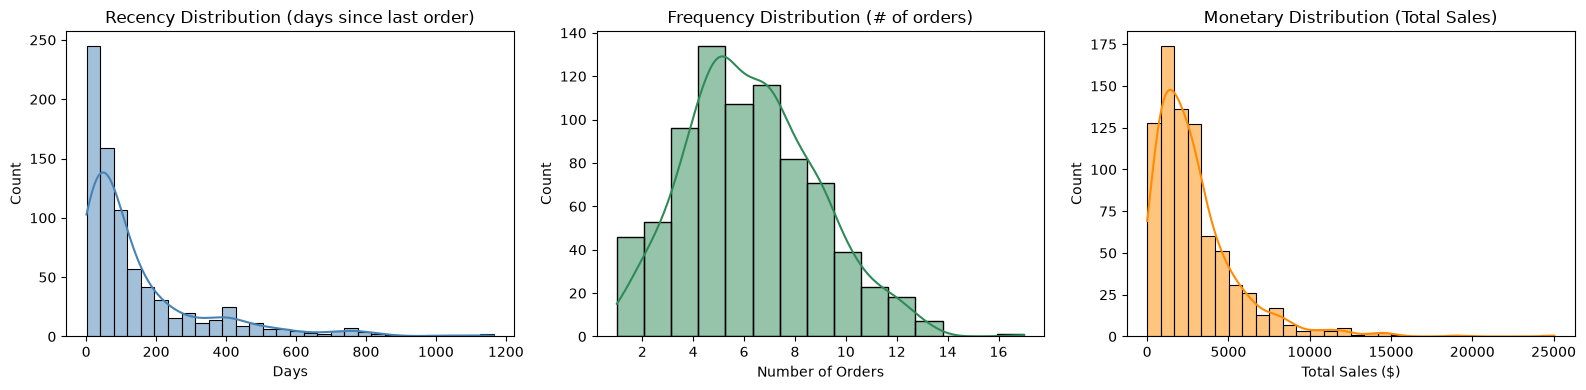

In [21]:
# 4.1 Distribution of the three RFM metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution (days since last order)')
axes[0].set_xlabel('Days')

sns.histplot(rfm['Frequency'], bins=15, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Frequency Distribution (# of orders)')
axes[1].set_xlabel('Number of Orders')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2], color='darkorange')
axes[2].set_title('Monetary Distribution (Total Sales)')
axes[2].set_xlabel('Total Sales ($)')

plt.tight_layout()
plt.show()

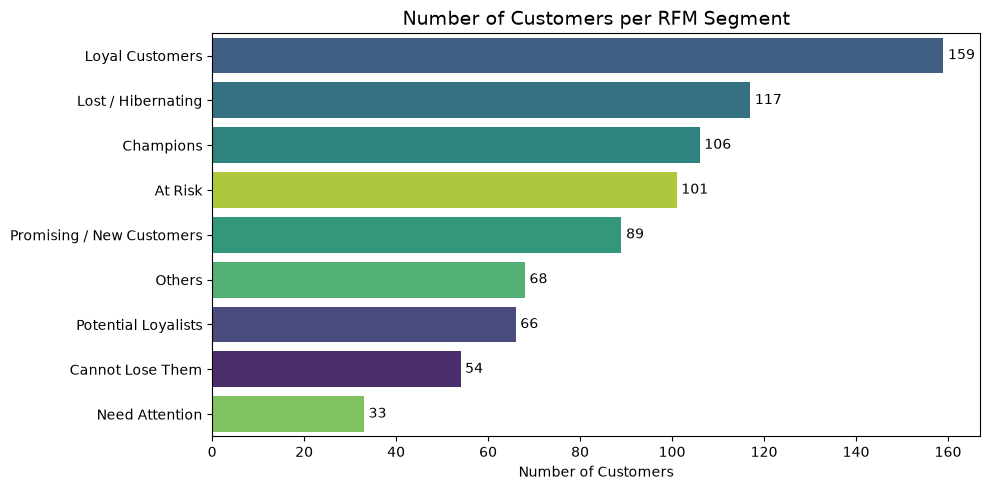

In [22]:
# 4.2 Customer Segment Size (count)
plt.figure(figsize=(10, 5))
segment_order = rfm['Customer_Segment'].value_counts().index
ax = sns.countplot(data=rfm, y='Customer_Segment', order=segment_order, hue='Customer_Segment', palette='viridis', legend=False)
plt.title('Number of Customers per RFM Segment', fontsize=14)
plt.xlabel('Number of Customers')
plt.ylabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 1, p.get_y() + 0.4), va='center')
plt.tight_layout()
plt.show()

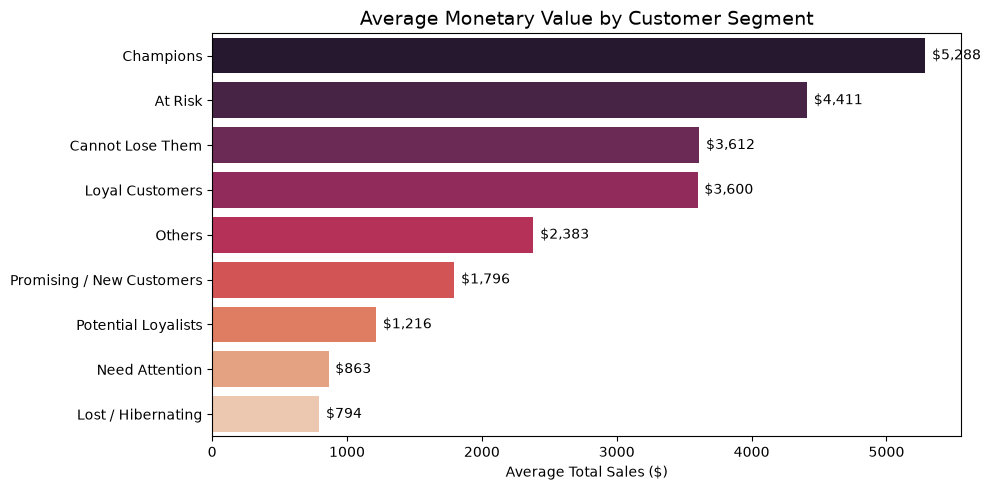

In [23]:
# 4.3 Average Monetary Value per Segment
plt.figure(figsize=(10, 5))
avg_mon = rfm.groupby('Customer_Segment')['Monetary'].mean().sort_values(ascending=False)
ax = sns.barplot(x=avg_mon.values, y=avg_mon.index, hue=avg_mon.index, palette='rocket', legend=False)
plt.title('Average Monetary Value by Customer Segment', fontsize=14)
plt.xlabel('Average Total Sales ($)')
plt.ylabel('')
for i, v in enumerate(avg_mon.values):
    ax.text(v + 50, i, f'${v:,.0f}', va='center')
plt.tight_layout()
plt.show()

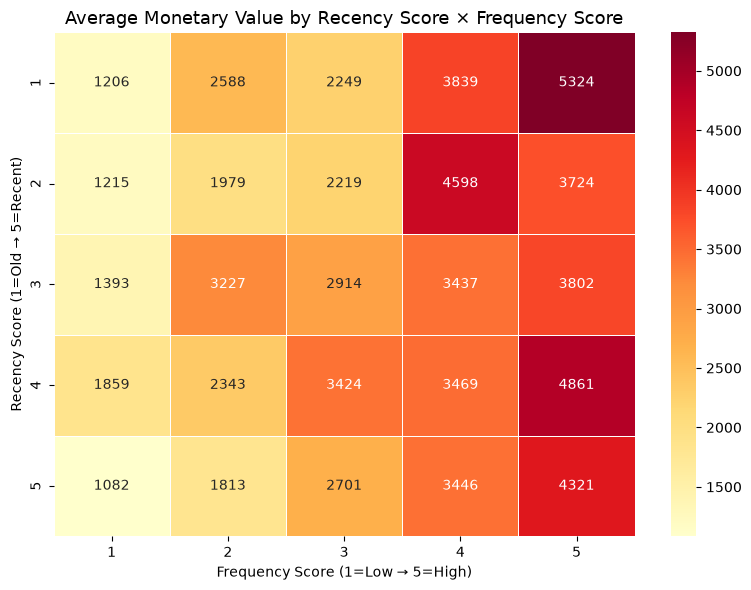

In [24]:
# 4.4 Classic RFM Heatmap – Average Monetary by R-Score × F-Score
heatmap_data = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Monetary Value by Recency Score × Frequency Score', fontsize=13)
plt.xlabel('Frequency Score (1=Low → 5=High)')
plt.ylabel('Recency Score (1=Old → 5=Recent)')
plt.tight_layout()
plt.show()

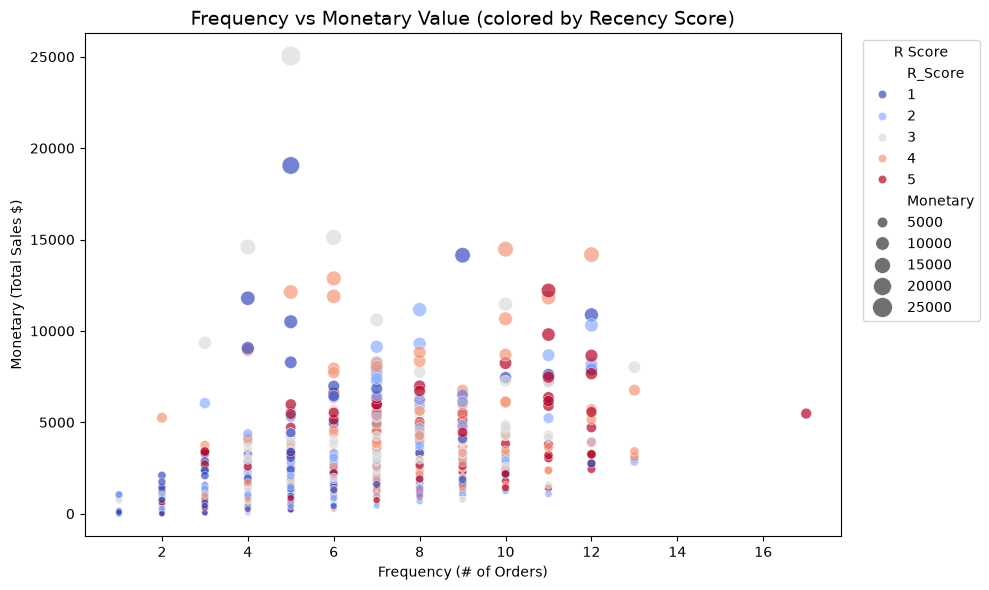

In [25]:
# 4.5 Scatter plot: Frequency vs Monetary colored by Recency Score
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary', hue='R_Score',
    palette='coolwarm', size='Monetary', sizes=(20, 200), alpha=0.7
)
plt.title('Frequency vs Monetary Value (colored by Recency Score)', fontsize=14)
plt.xlabel('Frequency (# of Orders)')
plt.ylabel('Monetary (Total Sales $)')
plt.legend(title='R Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

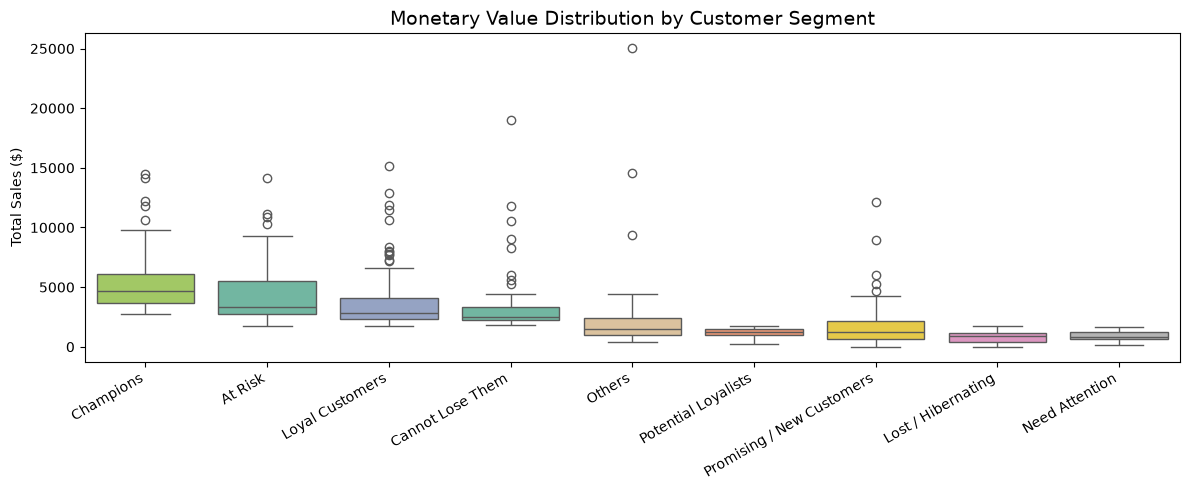

In [26]:
# 4.6 Box plots of Monetary by Segment
plt.figure(figsize=(12, 5))
order = rfm.groupby('Customer_Segment')['Monetary'].median().sort_values(ascending=False).index
sns.boxplot(data=rfm, x='Customer_Segment', y='Monetary', order=order, hue='Customer_Segment', palette='Set2', legend=False)
plt.xticks(rotation=30, ha='right')
plt.title('Monetary Value Distribution by Customer Segment', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xlabel('')
plt.tight_layout()
plt.show()